### Zyxin segmentation and object feature analysis

with Patrick's 2D fixed image two types of Zyxin

Liya Ding, 2025.4

In [1]:
import os
import sys
import tifffile 
import czifile
import numpy as np

In [13]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.FA_object_segmentation import FA_obj_segmenter
from core.FA_obj_feature_extraction import FA_obj_feature_extractor
from utils.display_utils import display_fa_segmentation_panels
from utils.pre_processing_utils import intensity_normalization
from utils.vessel_2d import filament_2d_wrapper
from scipy.ndimage import gaussian_filter 
import scipy.ndimage as ndi

In [3]:
image_2D_4CH_dir =  '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125/Control'
front_mask_dir = '/mnt/d/lding/FA/data/FA_ML_Annabel_20250217/031125'

output_dir = '/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major'

major_fa_ch = 1
cellmask_ch = 3
supplementary_fa_ch = [0,2]

os.makedirs(output_dir, exist_ok=True)

method_ID = 'code_org_20250520'

csv_output_dir = os.path.join(output_dir, method_ID+'_csv')
plot_output_dir = os.path.join(output_dir, method_ID+'_plot')
seg_output_dir = os.path.join(output_dir, method_ID+'_seg')

pixel_size = 0.07
time_point = 0

os.makedirs(csv_output_dir, exist_ok=True)
os.makedirs(plot_output_dir, exist_ok=True)
os.makedirs(seg_output_dir, exist_ok=True)

sub_dirs = ['mask', 'seg', 'label', 'togglelabel', 'rgb']
for sub_dir in sub_dirs:
    os.makedirs(os.path.join(seg_output_dir, sub_dir), exist_ok=True)


### for each 3D stack run through MIP and 8th frame

In [4]:
# flag for some optinal parts
flag_plot = True
flag_plot_save = True
flag_seg_save = True
flag_csv_save = True
flag_panel_plot = True
flag_run_all  = False

In [5]:
# select the cells that are single/disconnected and complete
ctrl_one_cell_list = [0,1,2,3,4,5,6,7,8,9]

In [19]:
# for all tif files 
filenames = [x for x in os.listdir(image_2D_4CH_dir) if os.path.isfile(os.path.join(image_2D_4CH_dir, x)) and ('.czi' in x)]

# # if not in run all mode, only test with the first image of the first movie
# if not flag_run_all:
#     filenames = filenames[:2]

# for filenameID in range(0,len(filenames)):
for filenameID in range(0,1):
    
    filename = filenames[filenameID]

    number = int(filename[-6:-4])
    # if number not in ctrl_one_cell_list:
    #     continue

    input_multich_img = np.squeeze(czifile.imread(os.path.join(image_2D_4CH_dir,filename)))
    # input_multich_img = np.transpose(input_multich_img, (2, 0, 1))
    major_FA_img = input_multich_img[3, :, :]
    second_FA_img = input_multich_img[1, :, :]

    norm_major_FA_img = intensity_normalization(major_FA_img,[10,40])
    norm_second_FA_img = intensity_normalization(second_FA_img,[10,40])

    smooth_major_FA_img = gaussian_filter(norm_major_FA_img, sigma=1, mode="nearest", truncate=3)
    smooth_second_FA_img = gaussian_filter(norm_second_FA_img, sigma=1, mode="nearest", truncate=3)

    f2_param = [[1, 0.5]]
    major_FA_res_1 = filament_2d_wrapper(smooth_major_FA_img, f2_param)
    f2_param = [[2, 0.5]]
    major_FA_res_2 = filament_2d_wrapper(smooth_major_FA_img, f2_param)
    f2_param = [[3, 0.5]]
    major_FA_res_3 = filament_2d_wrapper(smooth_major_FA_img, f2_param)

    response = -1 * (1 ** 2) * ndi.gaussian_laplace(smooth_second_FA_img, 1)
        


/mnt/d/lding/UbuntuGitCodes/focal_adhesion_clustering/utils/img_utils.py:107: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return a[index]


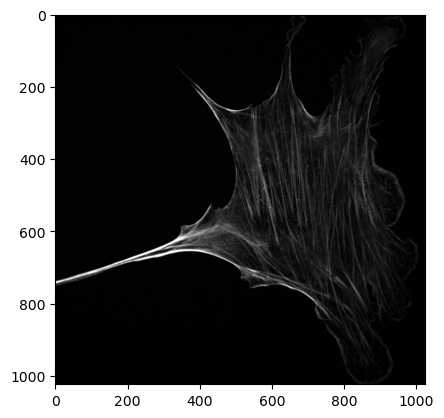

In [20]:
import matplotlib.pyplot as plt
plt.imshow(major_FA_img,cmap="gray")

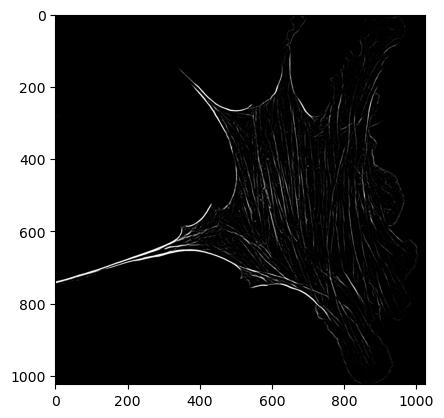

In [21]:
import matplotlib.pyplot as plt
plt.imshow(major_FA_res_1,cmap="gray")
tifffile.imwrite('/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ch4_vessel1.tiff',major_FA_res_1)

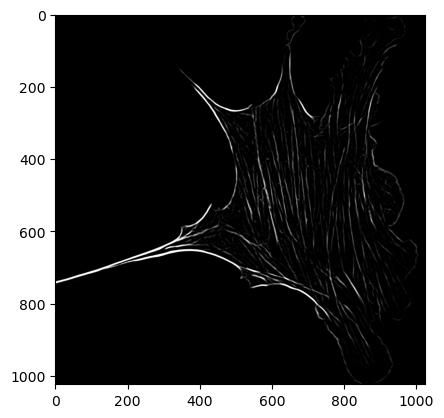

In [22]:
import matplotlib.pyplot as plt
plt.imshow(major_FA_res_2,cmap="gray")
tifffile.imwrite('/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ch4_vessel2.tiff',major_FA_res_2)

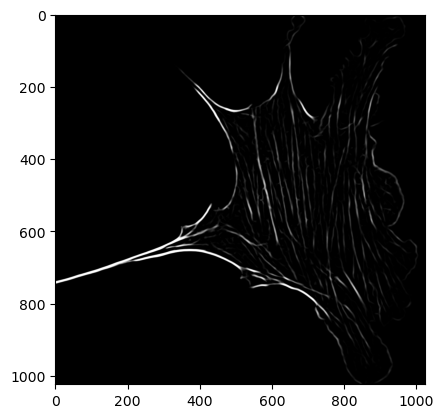

In [23]:
import matplotlib.pyplot as plt
plt.imshow(major_FA_res_3,cmap="gray")
tifffile.imwrite('/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ch4_vessel3.tiff',major_FA_res_3)

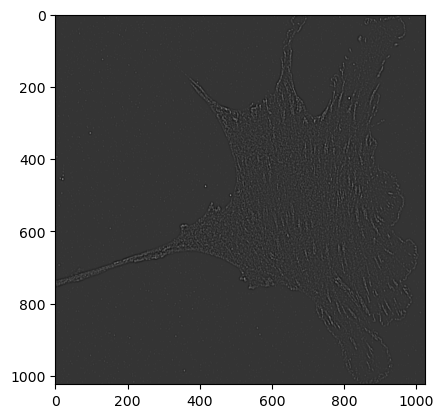

In [ ]:

plt.imshow(response,cmap="gray")
tifffile.imwrite('/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ch2_dot.tiff',response)

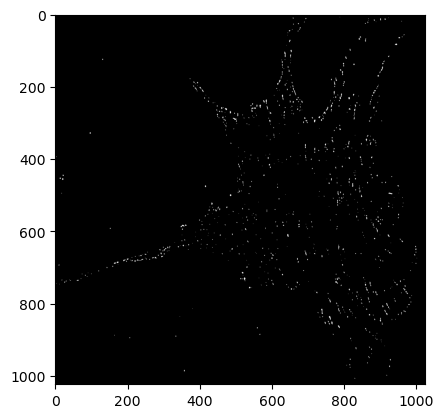

In [31]:
plt.imshow(response>0.05,cmap="gray")
tifffile.imwrite('/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ch2_dot_seg.tiff',response>0.05)

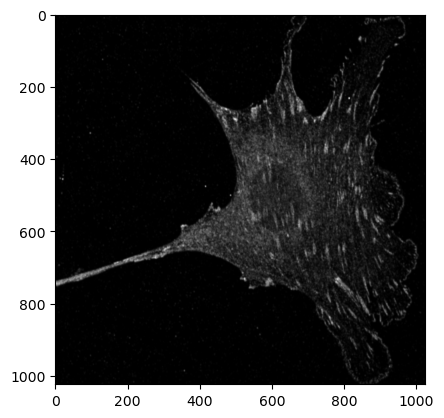

In [25]:
plt.imshow(smooth_second_FA_img,cmap="gray")
